# 04. KPI 기반 모델 평가

용해탱크 KPI MLOps v1 — Notebook 기반 모델 개발

## 평가 원칙

임계값은 검증 데이터로만 선택하고, 최종 테스트에서는 고정합니다. Accuracy보다 NG Recall, NG Precision, F2-score와 정상 구간 오경보율을 중심으로 판단합니다.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, fbeta_score
from tensorflow import keras

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data/processed"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

TARGET_RECALL = 0.90
TARGET_PRECISION = 0.60
MAX_NORMAL_FALSE_ALARM_RATE = 0.05

In [2]:
model = keras.models.load_model(ARTIFACT_DIR / "model.keras")
datasets = {}

for name in ["validation", "test_ng", "test_normal"]:
    X = np.load(DATA_DIR / f"X_{name}.npy")
    y = np.load(DATA_DIR / f"y_{name}.npy")
    probability = model.predict(X, batch_size=512, verbose=0).ravel()
    datasets[name] = (y, probability)
    print(name, "samples:", len(y), "NG ratio:", y.mean())

validation samples: 10080 NG ratio: 0.2883928571428571
test_ng samples: 10080 NG ratio: 0.03125
test_normal samples: 23039 NG ratio: 0.0


In [3]:
def calculate_metrics(y_true, probability, threshold):
    prediction = (probability >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "ng_precision": float(precision_score(y_true, prediction, zero_division=0)),
        "ng_recall": float(recall_score(y_true, prediction, zero_division=0)),
        "f2": float(fbeta_score(y_true, prediction, beta=2, zero_division=0)),
        "false_alarm_rate": float(fp / (fp + tn)) if fp + tn else 0.0,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

y_validation, p_validation = datasets["validation"]
threshold_table = pd.DataFrame([
    calculate_metrics(y_validation, p_validation, threshold)
    for threshold in np.arange(0.05, 0.96, 0.01)
])

eligible = threshold_table[
    (threshold_table["ng_recall"] >= TARGET_RECALL)
    & (threshold_table["ng_precision"] >= TARGET_PRECISION)
]

selection_met_validation_kpi = not eligible.empty

selected = (eligible if selection_met_validation_kpi else threshold_table).sort_values(
    ["f2", "ng_recall"], ascending=False
).iloc[0]

SELECTED_THRESHOLD = float(selected["threshold"])

print("selected threshold:", SELECTED_THRESHOLD)
print("validation KPI satisfied:", selection_met_validation_kpi)

display(threshold_table.sort_values("f2", ascending=False).head(10))

selected threshold: 0.05
validation KPI satisfied: False


,threshold,ng_precision,ng_recall,f2,false_alarm_rate,tn,fp,fn,tp
0,0.05,0.288393,1.0,0.669569,1.0,0,7173,0,2907
1,0.06,0.288393,1.0,0.669569,1.0,0,7173,0,2907
2,0.07,0.288393,1.0,0.669569,1.0,0,7173,0,2907
3,0.08,0.288393,1.0,0.669569,1.0,0,7173,0,2907
4,0.09,0.288393,1.0,0.669569,1.0,0,7173,0,2907
5,0.10,0.288393,1.0,0.669569,1.0,0,7173,0,2907
6,0.11,0.288393,1.0,0.669569,1.0,0,7173,0,2907
7,0.12,0.288393,1.0,0.669569,1.0,0,7173,0,2907
8,0.13,0.288393,1.0,0.669569,1.0,0,7173,0,2907
9,0.14,0.288393,1.0,0.669569,1.0,0,7173,0,2907


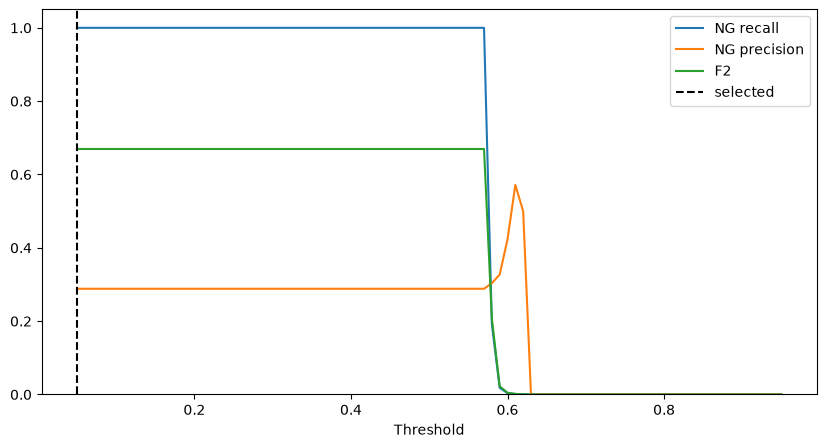

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_table["threshold"], threshold_table["ng_recall"], label="NG recall")
ax.plot(threshold_table["threshold"], threshold_table["ng_precision"], label="NG precision")
ax.plot(threshold_table["threshold"], threshold_table["f2"], label="F2")
ax.axvline(SELECTED_THRESHOLD, color="black", linestyle="--", label="selected")
ax.set_xlabel("Threshold")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

In [5]:
results = {
    name: calculate_metrics(y_true, probability, SELECTED_THRESHOLD)
    for name, (y_true, probability) in datasets.items()
}
result_table = pd.DataFrame(results).T
display(result_table)

deployment_approved = bool(
    results["test_ng"]["ng_recall"] >= TARGET_RECALL
    and results["test_ng"]["ng_precision"] >= TARGET_PRECISION
    and results["test_normal"]["false_alarm_rate"] <= MAX_NORMAL_FALSE_ALARM_RATE
)
print("배포 KPI 승인:", deployment_approved)

,threshold,ng_precision,ng_recall,f2,false_alarm_rate,tn,fp,fn,tp
validation,0.05,0.288393,1.0,0.669569,1.0,0.0,7173.0,0.0,2907.0
test_ng,0.05,0.031250,1.0,0.138889,1.0,0.0,9765.0,0.0,315.0
test_normal,0.05,0.000000,0.0,0.000000,1.0,0.0,23039.0,0.0,0.0


배포 KPI 승인: False


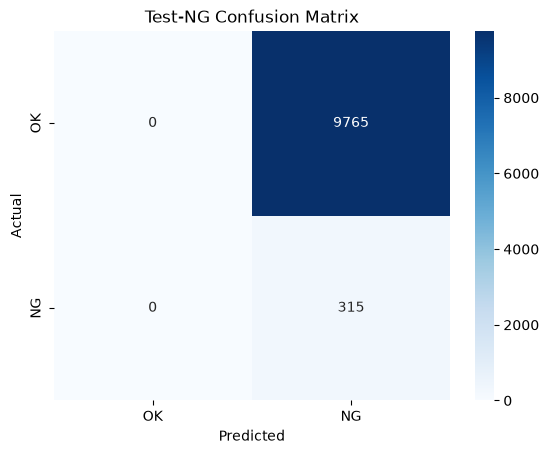

In [6]:
y_test_ng, p_test_ng = datasets["test_ng"]
pred_test_ng = (p_test_ng >= SELECTED_THRESHOLD).astype("int8")
matrix = confusion_matrix(y_test_ng, pred_test_ng, labels=[0, 1])

sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["OK", "NG"], yticklabels=["OK", "NG"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test-NG Confusion Matrix")
plt.show()

In [8]:
report = {
    "selected_threshold": SELECTED_THRESHOLD,
    "validation_kpi_satisfied": bool(selection_met_validation_kpi),
    "deployment_approved": deployment_approved,
    "targets": {
        "ng_recall_min": TARGET_RECALL,
        "ng_precision_min": TARGET_PRECISION,
        "normal_false_alarm_rate_max": MAX_NORMAL_FALSE_ALARM_RATE,
    },
    "metrics": results,
}

(ARTIFACT_DIR / "evaluation.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

print("평가 결과 저장:", ARTIFACT_DIR / "evaluation.json")

평가 결과 저장: E:\academy\AI-DL\melting-tank-kpi-mlops_notebook_v1.0.0\artifacts\evaluation.json


## 최종 결론 작성

- KPI를 모두 통과했다면: v2의 재현 가능한 학습 파이프라인으로 이전할 후보 모델이다.
- 하나라도 통과하지 못했다면: 배포하지 않고 타깃 정의, 특성, 기간별 분포 변화와 추가 데이터를 재검토한다.

모델이 정상적으로 실행되었다는 사실과 운영에 배포할 수 있다는 판단은 서로 다릅니다.